In [1]:
!pip install afinn
from afinn import Afinn
import re
import pandas as pd

In [3]:
# Read dataframe
df = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/guardian_clean_sentiment_analysis.csv")
df.head(10)

# Initialize afinn
afinn = Afinn()

df['content_sentiment'] = df['cleaned_text'].apply(afinn.score)

# Check results
print(df[['cleaned_text', 'content_sentiment']].head())

# Statistics of results
print("\n Statistics of Sentiment Analysis Resutls")
print("The Number of Positive Content:", len(df[df['content_sentiment'] > 0]))
print("The Number of Negative Content:", len(df[df['content_sentiment'] < 0]))
print("The Number of Neutral Content:", len(df[df['content_sentiment'] == 0]))

                                        cleaned_text  content_sentiment
0  move left antiabortion advocates reeling food ...               17.0
1  supporters abortion rights spent much last try...               45.0
2  planned parenthood clinics wisconsin stop prov...               -9.0
3  belén pseudonym yearold woman arrived hospital...              -10.0
4  “fun little game” launched antiabortion activi...              -30.0

 Statistics of Sentiment Analysis Resutls
The Number of Positive Content: 202
The Number of Negative Content: 295
The Number of Neutral Content: 3


In [4]:

# Initialize AFINN 
afinn = Afinn()

# List of words that reverse meaning
NEGATION_WORDS = [
        'not', 'no', 'never', 'nothing', 'nowhere', 'noone', 'none', 'dont', 'doesnt', 'didnt', 'cant', 'couldnt', 'wont', 'wouldnt',
        'shouldnt', 'isnt', 'arent', 'havent', 'hasnt', 'hadnt',
        "don't", "doesn't", "didn't", "can't", "couldn't", "won't", 
        "wouldn't", "shouldn't", "isn't", "aren't", "haven't", "hasn't", "hadn't"
]

def analyze_sentiment_negation(text):
    """
    Simple sentiment analysis that handles negation words like 'not'
    """
    # prepare data
    text_str = str(text)
    words = text_str.split()
    
    total_score = 0
    i = 0  
    
    while i < len(words):
        word = words[i]
        word_score = afinn.score(word)
        
        # test negation and emotional word
        if word in NEGATION_WORDS and i + 1 < len(words):
            next_word = words[i + 1]
            next_score = afinn.score(next_word)
            if next_score != 0:
                total_score -= next_score  
                i += 2  
                continue  
        
        
        total_score += word_score
        i += 1  
    
    return total_score
# Test the function
print("TESTING SIMPLE SENTIMENT ANALYSIS:")

test_texts = [
    "I love this movie",           
    "I do not love this movie",    
]

for text in test_texts:
    score = analyze_sentiment_negation(text)
    
    # Determine sentiment label
    if score > 0:
        sentiment = "POSITIVE"
    elif score < 0:
        sentiment = "NEGATIVE"
    else:
        sentiment = "NEUTRAL"

    print(text)
    print("Score:", score, "→", sentiment)
    print()

TESTING SIMPLE SENTIMENT ANALYSIS:
I love this movie
Score: 3.0 → POSITIVE

I do not love this movie
Score: -3.0 → NEGATIVE



In [5]:
# Negation processing
df['content_processed_sentiment'] = df['cleaned_text'].apply(analyze_sentiment_negation)

# Emotional Label
def get_sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df['content_sentiment_label'] =df['content_processed_sentiment'].apply(get_sentiment_label)

# Results
print("Sentiment Analysis Results for the First 10 Articles:")
result_columns = ['title', 'content_processed_sentiment', 'content_sentiment_label']
print(df[result_columns].head(10))

Sentiment Analysis Results for the First 10 Articles:
                                               title  \
0  Anti-abortion groups furious as FDA approves g...   
1  What Tuesday’s elections mean for the future o...   
2  Wisconsin Planned Parenthood clinics suspend a...   
3  Belén review – gripping true story of woman un...   
4  SA attorney general refers anti-abortion activ...   
5  Louisiana issues warrant for California doctor...   
6  Farage urged to explain anti-abortion links to...   
7  Abortion pill providers targeted by new Texas ...   
8  Anti-abortion activists pardoned by Trump face...   
9    Tracking abortion laws across the United States   

   content_processed_sentiment content_sentiment_label  
0                         17.0                positive  
1                         45.0                positive  
2                        -13.0                negative  
3                        -10.0                negative  
4                        -30.0              

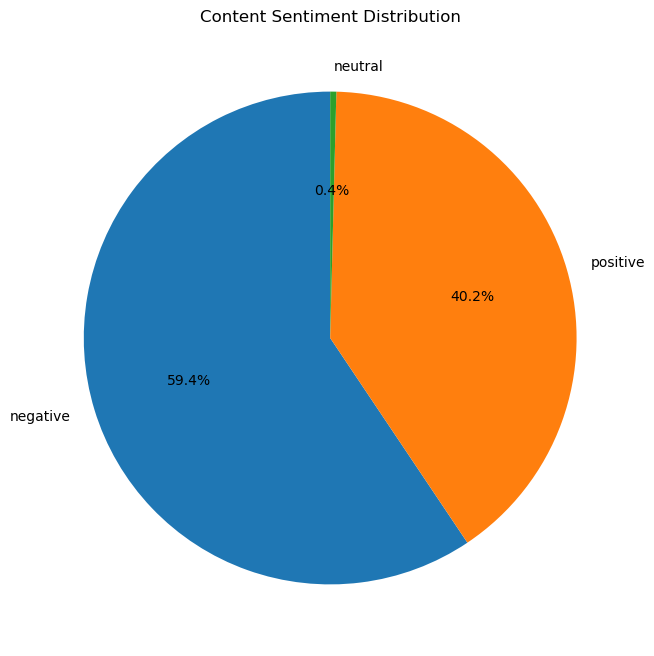

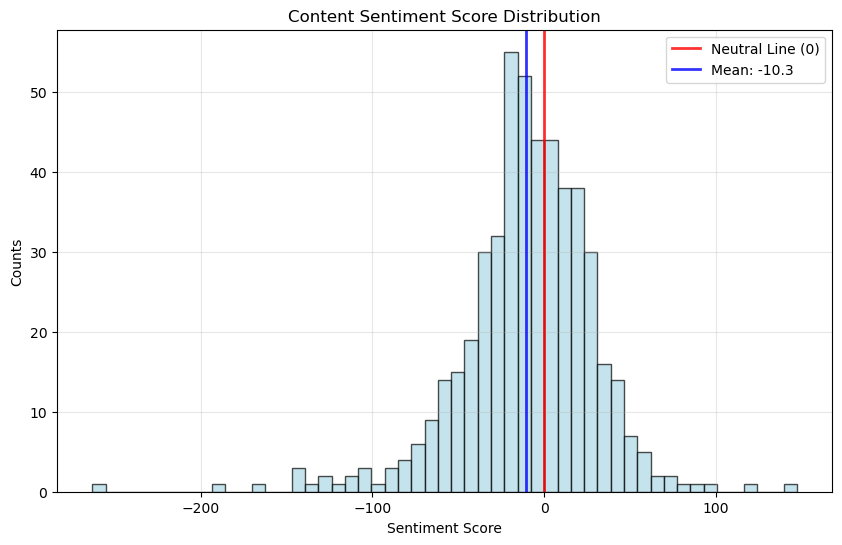

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 1: Content Sentiment Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
content_counts = df['content_sentiment_label'].value_counts()
plt.pie(content_counts.values, labels=content_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Content Sentiment Distribution')
plt.savefig('guardian_piechart', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Content Sentiment Score Distribution (Histogram)
plt.figure(figsize=(10, 6))
data = df['content_processed_sentiment']
mean_score = data.mean()

plt.hist(data, bins=53, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Neutral Line (0)')
plt.axvline(x=mean_score, color='blue', linestyle='-', alpha=0.8, linewidth=2, label='Mean: ' + str(round(mean_score, 2)))

plt.xlabel('Sentiment Score')
plt.ylabel('Counts')
plt.title('Content Sentiment Score Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('guardian_distribution', dpi=300, bbox_inches='tight')
plt.show()



In [7]:
# Generate Summary Report
print("AFINN Sentiment Analysis Summary Report     ")
print("Total number of articles:",len(df))
print("Average content sentiment score:", df['content_processed_sentiment'].mean())
print("\nContent sentiment distribution:")
print(df['content_sentiment_label'].value_counts())

# Find articles with most extreme sentiments
most_positive_content = df.loc[df['content_processed_sentiment'].idxmax()]
most_negative_content = df.loc[df['content_processed_sentiment'].idxmin()]

print("\nMost positive article:", most_positive_content['cleaned_text'])
print("Sentiment score:", most_positive_content['content_processed_sentiment'])
print("\nMost negative article:", most_negative_content['cleaned_text'])
print("Sentiment score:", most_negative_content['content_processed_sentiment'])

AFINN Sentiment Analysis Summary Report     
Total number of articles: 500
Average content sentiment score: -10.302

Content sentiment distribution:
content_sentiment_label
negative    297
positive    201
neutral       2
Name: count, dtype: int64

Most positive article: wrap blog evening major developments today south wales women easier access abortion pills after both houses passed bill allowing nurse practitioners registered midwives prescribe medication wages picked little stronger expected start continue clawing back purchasing power households lost three high inflation anthony albanese australia “no more important relationship one indonesia” before setting off jakarta australia’s ageing coal power stations broke down times during hotter months report reliability watch australian electoral commission aec confirmed one container ballot papers nsw seat barton temporarily misplaced during count transport officer found possession container macquarie bank’s stockbroker arm sued corporat